In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt


=== BASIC INFORMATION ===
Shape: (2291, 18)

Columns:
['index', 'qrCode', 'location', 'irrigationProvided', 'nitrogenTreatment', 'poundsOfNitrogenPerAcre', 'experiment', 'plotLength', 'block', 'row', 'range', 'plotNumber', 'genotype', 'plantingDate', 'totalStandCount', 'daysToAnthesis', 'GDDToAnthesis', 'yieldPerAcre']

=== MISSING VALUES (RAW) ===
index                         0
qrCode                      134
location                      0
irrigationProvided          134
nitrogenTreatment           118
poundsOfNitrogenPerAcre       0
experiment                   16
plotLength                  134
block                       134
row                           0
range                         0
plotNumber                  134
genotype                    134
plantingDate                134
totalStandCount            1152
daysToAnthesis             1282
GDDToAnthesis              1283
yieldPerAcre                160
dtype: int64

=== TARGET ANALYSIS ===
Total rows: 2291
Valid 'yieldPerAcr

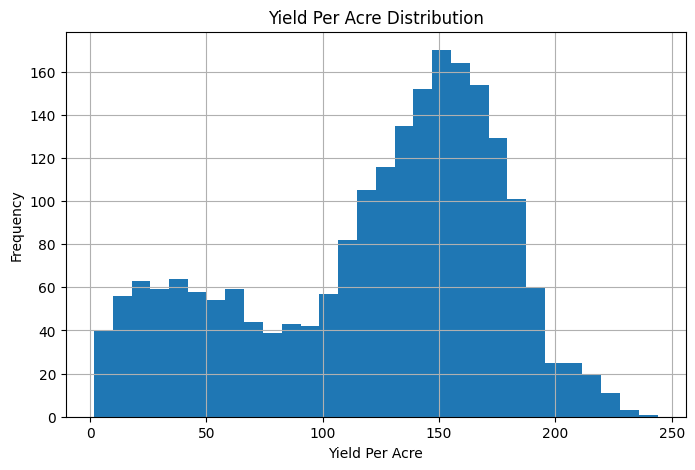


Cleaned dataset saved to ../data/processed/2022_clean_groundtruth.csv


In [14]:

# Load raw dataset
df = pd.read_csv("../data/raw/2022/DataPublication_final/GroundTruth/HYBRID_HIPS_V3.5_ALLPLOTS.csv")

print("=== BASIC INFORMATION ===")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\n=== MISSING VALUES (RAW) ===")
missing = df.isnull().sum()
print(missing)

print("\n=== TARGET ANALYSIS ===")
total_rows = len(df)
valid_rows = df["yieldPerAcre"].notna().sum()
missing_yield = df["yieldPerAcre"].isna().sum()

print(f"Total rows: {total_rows}")
print(f"Valid 'yieldPerAcre' entries: {valid_rows}")
print(f"Missing 'yieldPerAcre' entries: {missing_yield}")

# Keep only rows with target values
df_clean = df[df["yieldPerAcre"].notna()].copy()
print("\nCleaned Data Shape:", df_clean.shape)

# Drop columns that are just identifiers / not useful for modeling
df_clean = df_clean.drop(columns=["index", "qrCode"])

print("\n=== CLEANED COLUMNS ===")
print(df_clean.columns.tolist())

print("\n=== CLEANED HEAD ===")
print(df_clean.head())

print("\n=== MISSING VALUES (CLEANED) ===")
print(df_clean.isna().sum())

print("\n=== CLEANED INFO ===")
df_clean.info()

print("\n=== YIELD SUMMARY ===")
print(df_clean["yieldPerAcre"].describe())

print("\n=== UNIQUE VALUES PER COLUMN ===")
print(df_clean.nunique())

# Plot target distribution
plt.figure(figsize=(8, 5))
df_clean["yieldPerAcre"].hist(bins=30)
plt.title("Yield Per Acre Distribution")
plt.xlabel("Yield Per Acre")
plt.ylabel("Frequency")
plt.show()

# Save cleaned dataset
os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv("../data/processed/2022_clean_groundtruth.csv", index=False)

print("\nCleaned dataset saved to ../data/processed/2022_clean_groundtruth.csv")

In [15]:
print(df.shape)
print(df.dtypes)
print(df.head())

(2291, 18)
index                        int64
qrCode                      object
location                    object
irrigationProvided         float64
nitrogenTreatment           object
poundsOfNitrogenPerAcre      int64
experiment                  object
plotLength                 float64
block                      float64
row                          int64
range                        int64
plotNumber                 float64
genotype                    object
plantingDate                object
totalStandCount            float64
daysToAnthesis             float64
GDDToAnthesis              float64
yieldPerAcre               float64
dtype: object
   index qrCode location  irrigationProvided nitrogenTreatment  \
0      8    NaN     Ames                 NaN               NaN   
1     11    NaN     Ames                 NaN               NaN   
2      0    NaN     Ames                 NaN               NaN   
3      9    NaN     Ames                 NaN               NaN   
4     12    NaN